
REZULTATI: SAMO TEKST
       Algoritam     Score
0         KMeans  0.008745
1      MiniBatch -0.003865
2  Agglomerative  0.000253
3       Spectral  0.005373
4         DBSCAN  0.000000


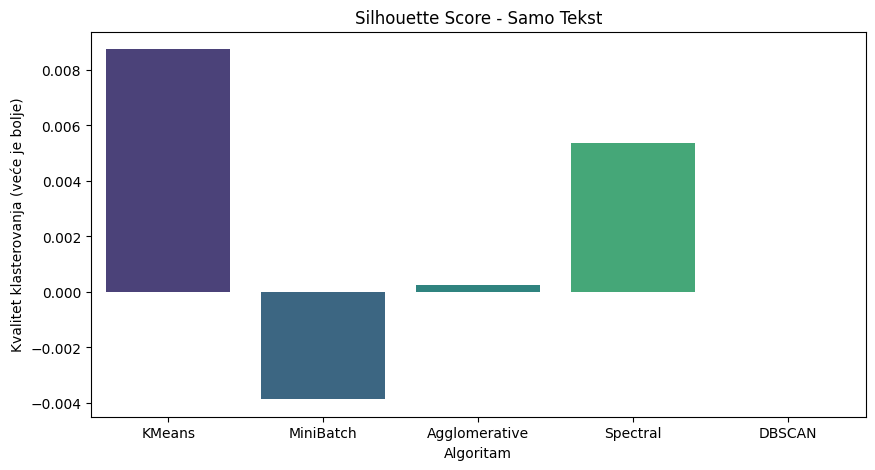

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD  
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score

# Ucitavanje i priprema uzorka 
df = pd.read_csv("Reviews_sample_balanced.csv").dropna(subset=['Text']).sample(2000, random_state=42)

# Vektorizacija teksta
tfidf = TfidfVectorizer(max_features=15000, stop_words='english')
X = tfidf.fit_transform(df['Text']).toarray() 

results = {}

# KMeans
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km = km.fit_predict(X)
results['KMeans'] = silhouette_score(X, labels_km)

# MiniBatchKMeans
mb = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=100)
labels_mb = mb.fit_predict(X)
results['MiniBatch'] = silhouette_score(X, labels_mb)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(X)
results['Agglomerative'] = silhouette_score(X, labels_agg)

# Spectral
spec = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
labels_spec = spec.fit_predict(X)
results['Spectral'] = silhouette_score(X, labels_spec)

# DBSCAN (sa proverom)
db = DBSCAN(eps=0.5, min_samples=5)
labels_db = db.fit_predict(X)
if len(set(labels_db)) > 1:
    results['DBSCAN'] = silhouette_score(X, labels_db)
else:
    results['DBSCAN'] = "Nije našao klastere"

df_res = pd.DataFrame(list(results.items()), columns=['Algoritam', 'Score'])
df_res['Score'] = pd.to_numeric(df_res['Score'], errors='coerce').fillna(0.0)

print("\nREZULTATI: SAMO TEKST")
print(df_res)

# Grafik
plt.figure(figsize=(10,5))
sns.barplot(x='Algoritam', y='Score', data=df_res, hue='Algoritam', palette='viridis', legend=False)
plt.title('Silhouette Score - Samo Tekst')
plt.ylabel('Kvalitet klasterovanja (veće je bolje)')
plt.show()

In [7]:
df_res.to_csv("rezultati_text.csv", index=False)